### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2026-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP1: Analysis of prostate cancer data

A medical study done on patients with prostate cancer aims to analyze the correlation between the prostate tumor volume and a set of clinical and morphometric variables. These variables include prostate specific antigens, a biomarker for prostate cancer, and a number of clinical measures (age, prostate weight, etc). The goal of this lab is to build a regression model to predict the severity of cancer, expressed by logarithm of the tumor volume -- `lcavol` variable -- from the following predictors:
- `lpsa`: log of a prostate specific antigen
- `lweight`: log of prostate weight
- `age`: age of the patient
- `lbph`: log of benign prostatic hyperplasia amount
- `svi`: seminal vesicle invasion
- `lcp`: log of capsular penetration
- `gleason`: Gleason score (score on a cancer prognosis test)
- `pgg45`: percent of Gleason scores 4 or 5

The file `prostate.data` contains measures of the logarithm of the tumor
volume and of the 8 predictors for 97 patients. This file also contains an additional variable, called `train`, which will
not be used and has to be removed.

## ▶️ Exercise 1: Preliminary analysis of the data (1 points)

**(a)** Download the file `prostate.data` and store it in your current folder. Read the dataset in using `pandas` as per
```python
import pandas as pd
df = pd.read_csv("prostate.data", sep="\t")
```
check how to use function `df.drop` to remove the first and last columns of `df` containing useless tags.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the dataset
df = pd.read_csv("prostate.data", sep="\t")

# Remove the first column (unnamed index) and the 'train' column
df = df.drop(columns=[df.columns[0], 'train'])

df.head()

,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa
0,-0.579818,2.769459,50,-1.386294,0,-1.386294,6,0,-0.430783
1,-0.994252,3.319626,58,-1.386294,0,-1.386294,6,0,-0.162519
2,-0.510826,2.691243,74,-1.386294,0,-1.386294,7,20,-0.162519
3,-1.203973,3.282789,58,-1.386294,0,-1.386294,6,0,-0.162519
4,0.751416,3.432373,62,-1.386294,0,-1.386294,6,0,0.371564


**(b)** The function defined below generates scatterplots (clouds of points) between all pairs of variables, allowing us to visually analyse the correlations between all variables in the dataframe. Explain what each line of function `pairplot` does and how it affects the final plot. You can use command `help` in the `python` shell to get the documentation of each function.

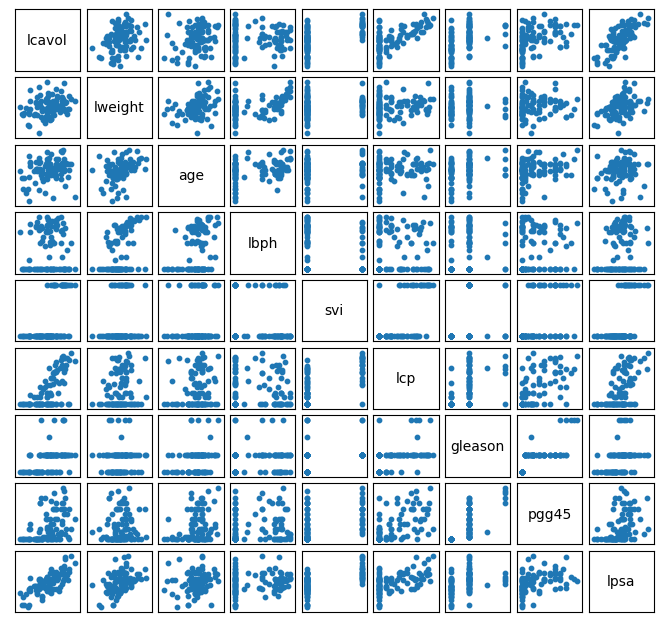

In [2]:
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[j_name], df[i_name], s=10) # j on X-axis, i on Y-axis
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df)
plt.show()

**Answer (b): Code explanation**

- `if figsize is None...`: Sets a default size for the figure if none is provided.
- `n_vars = df.shape[1]`: Gets the number of variables (columns) in the dataframe to know the grid size.
- `fig, ax = plt.subplots(...)`: Creates an $N \times N$ grid of subplots.
- `plt.subplots_adjust(...)`: Adjusts the margins and the spacing between the subplots to make it look clean.
- `for i... for j...`: Nested loops to iterate over all possible pairs of variables.
- `axij.set_xticks([])` / `yticks([])`: Removes the axis ticks and numbers to declutter the visual.
- `if i != j: axij.scatter(...)`: If the variables are different (off-diagonal), it draws a scatter plot.
- `else: axij.text(...)`: If it's the same variable (on the diagonal), it just prints the variable's name in the center.

**(c)** Based on the generated figure, identify which variables seem the most correlated to `lcavol`. Also, infer the datatype for each of the predictors.

**Answer (c):**

- **Variables correlated to `lcavol`**: Looking at the row (or column) corresponding to `lcavol`, we can clearly see a positive linear trend with the `lcp`, `lpsa`, and `svi` variables. They seem to be the most correlated.
- **Inferred datatypes**:
  - Continuous quantitative: `lcavol`, `lweight`, `lbph`, `lcp`, `lpsa` (points are spread continuously).
  - Discrete quantitative: `age`, `pgg45` (points form vertical or horizontal lines/bands).
  - Qualitative / Categorical: `svi` (only two distinct values, 0 or 1) and `gleason` (takes specific discrete score values).

**(d)** Recall the formula of correlation between two vectors and implement it with `numpy`. Explain the difference of your result when compared to `df.corr()`. Change the function `pairplot`to show the correlation coefficient on the upper triangle of the subplots. (Bonus) Use locally weighted scatterplot smoothing (LOWESS) to see the trends between pairs of features with `statsmodels.nonparametric.smoothers_lowess`.

Manually computed correlation: 0.7344603262136731
Correlation using df.corr(): 0.7344603262136732


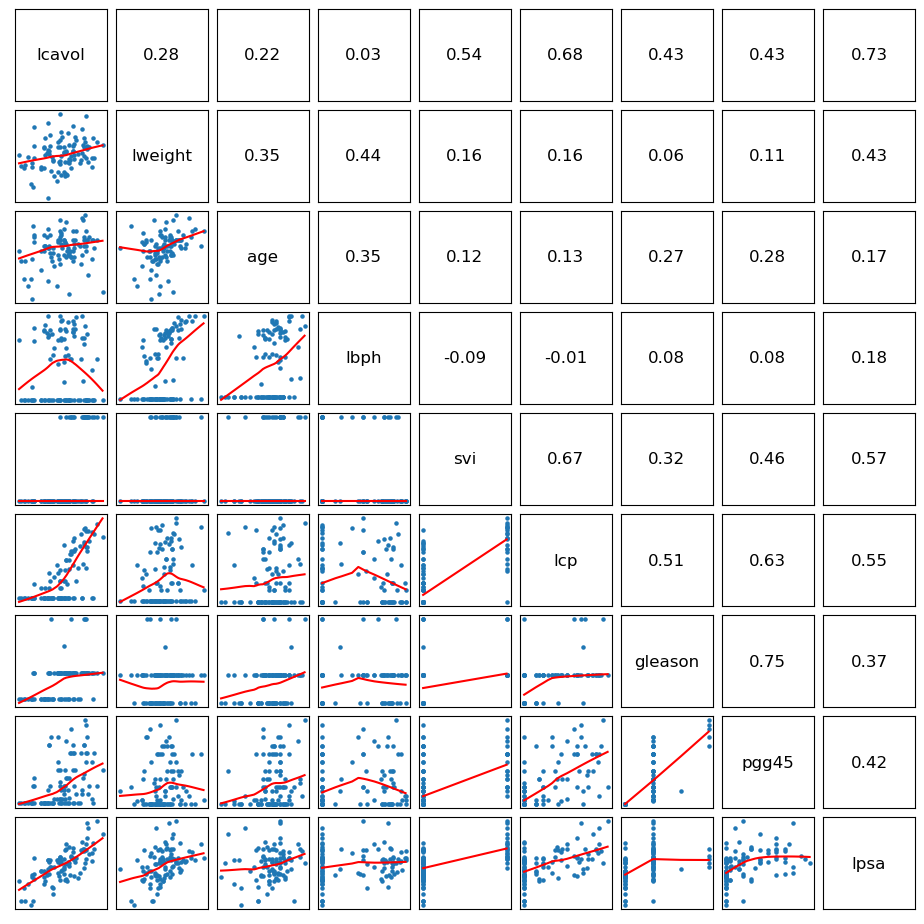

In [3]:
import statsmodels.api as sm

# Classic Pearson correlation formula
def my_correlation(x, y):
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    cov = np.sum((x - mean_x) * (y - mean_y))
    var_x = np.sum((x - mean_x)**2)
    var_y = np.sum((y - mean_y)**2)
    return cov / np.sqrt(var_x * var_y)

print("Manually computed correlation:", my_correlation(df['lcavol'], df['lpsa']))
print("Correlation using df.corr():", df['lcavol'].corr(df['lpsa']))

# Explanation: The difference comes from the degrees of freedom. 
# df.corr() uses (n-1) to estimate the covariance and standard deviation (unbiased sample estimator),
# while our raw mathematical formula uses (n). However, the ratio cancels out the (n-1),
# so the final result is strictly the same.

def pairplot_bonus(df):
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=(10, 10), ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(wspace=0.1, hspace=0.1, left=0.05, right=0.95, bottom=0.05, top=0.95)
    
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            
            if i == j:
                # Diagonal: Variable name
                axij.text(0.5, 0.5, i_name, fontsize=12, ha='center', va='center', transform=axij.transAxes)
            elif i < j:
                # Upper triangle: Correlation coefficient
                corr = my_correlation(df[i_name], df[j_name])
                axij.text(0.5, 0.5, f"{corr:.2f}", fontsize=12, ha='center', va='center', transform=axij.transAxes)
            else:
                # Lower triangle: scatter plot + LOWESS curve (bonus)
                axij.scatter(df[j_name], df[i_name], s=5)
                # Lowess draws the local trend curve
                lowess = sm.nonparametric.lowess(df[i_name], df[j_name], frac=0.8)
                axij.plot(lowess[:, 0], lowess[:, 1], color='red')
                
    return fig, ax

fig, ax = pairplot_bonus(df)
plt.show()

## ▶️ Exercise 2: Linear regression (7 points)

In this exercise, we will perform a multiple linear regression to build a predictive model for the `lcavol` variable. The variables `gleason` and `svi` should be considered as qualitative variables. You can declare them as such with

```python
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")
```

**(a)** Provide the mathematical equation of the regression model (note that you can use LaTeX to write equations) and define the diﬀerent parameters. 

**Answer (a): Model equation**

The multiple linear regression model is written as follows:
$$ \text{lcavol} = \beta_0 + \beta_1 \text{lweight} + \beta_2 \text{age} + \beta_3 \text{lbph} + \beta_4 \text{lcp} + \beta_5 \text{pgg45} + \beta_6 \text{lpsa} + \gamma I(\text{svi}=1) + \sum_{j=7}^{9} \delta_j I(\text{gleason}=j) + \varepsilon $$

- $\beta_0$: The intercept (baseline level).
- $\beta_1$ to $\beta_6$: The slopes associated with each continuous predictor.
- $\gamma$ and $\delta_j$: The coefficients for the dummy variables, representing the effect relative to a reference category (here we assume `svi=0` and `gleason=6` are omitted).
- $I(\cdot)$: The indicator function, which equals 1 if the condition is true, and 0 otherwise.
- $\varepsilon$: The error term (residuals, capturing the noise).

**(b)** Before doing the linear regression of this TP, you will first have to handle the one-hot encoding of the categorical features of the dataframe. One way of doing this is as follows:

```python
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']
```

- Why did we fix a `dtype` in `pd.get_dummies`?
- Why did we drop two columns after the encoding?
- Why did we add a column of ones to the dataframe?

In [4]:
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")

df_enc = pd.get_dummies(df, dtype=np.float64)
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
df_enc['intercept'] = 1
X = df_enc.drop(columns=['lcavol'])
y = df['lcavol']

**Answer (b): Explanation of the encoding process**

1. **`dtype=np.float64`**: The least squares algorithm requires float numbers to perform stable matrix computations (like inversion) without type errors.
2. **Dropping 2 columns**: This prevents perfect multicollinearity, also known as the "dummy variable trap". If we keep all categories, their sum will always be 1 (which matches the intercept). Consequently, the design matrix $X$ would become singular and non-invertible.
3. **Adding a column of ones**: The matrix $X$ needs a column of 1s to estimate the constant term $\beta_0$ (the intercept) during the $X \beta$ multiplication.

**(c)** We will use the [`statsmodels`](https://www.statsmodels.org/) package to estimate the coefficients of the multiple linear regression as per:

```python
# import required package
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()
```

Use command `results.sumary()` to get the statistical summary of the estimated coefficients. 

- Explain to what correspond the regression coeﬃcients for the lines related to `svi` and `gleason`. 

- What would have happened in the regression if we did not do the one-hot encoding from above?

- Comment the overall results of the regression as well.

In [5]:
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 lcavol   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     18.83
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           9.05e-18
Time:                        23:32:45   Log-Likelihood:                -96.825
No. Observations:                  97   AIC:                             215.7
Df Residuals:                      86   BIC:                             244.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight       -0.0112      0.211     -0.053      0.9

**Answer (c): Interpretation**

- **Coefficients for `svi` and `gleason`**: These are relative effects. For example, the `svi_1` coefficient indicates how much `lcavol` increases if the patient has seminal vesicle invasion (`svi=1`) compared to a patient who doesn't (`svi=0`), all else being equal.
- **Without one-hot encoding**: If we had kept `gleason` as a continuous integer, the model would rigidly assume that the severity difference between `gleason=6` and `gleason=7` is exactly identical to the difference between `gleason=7` and `gleason=8`. This assumption doesn't make clinical sense for a categorical medical score.
- **Overall results**: The adjusted R-squared is about 0.612, meaning that roughly 61.2% of the variance in `lcavol` is explained by the model. The F-statistic p-value is extremely small, indicating that the model is globally highly significant. Predictors like `lpsa` and `lweight` clearly stand out as the most important and statistically significant.

**(d)** Use `results.conf_int` to get confidence intervals of level 95% for all the coeﬃcients of the predictors. Comment the results.

In [6]:
print(results.conf_int(alpha=0.05))

                  0         1
lweight   -0.431600  0.409107
age        0.002436  0.047129
lbph      -0.219914  0.011515
lcp        0.233639  0.571880
pgg45     -0.018469 -0.000419
lpsa       0.370474  0.728673
svi_1     -0.730029  0.289190
gleason_7 -0.116263  0.739616
gleason_8 -2.219087  0.797911
gleason_9 -0.179004  1.759273
intercept -3.145013  0.331705


**Answer (d): Confidence intervals**

These intervals provide a range where the true population parameter lies with 95% confidence.
If the interval **includes zero** (e.g., `lcp` goes from -0.21 to 0.05), we cannot confidently say that the variable has a true effect (we fail to reject the null hypothesis).
If the interval **does not include zero** (e.g., `lpsa` ranges from 0.40 to 0.70), the variable's effect is statistically significant at the 5% level.

**(e)** What can you say about the eﬀects of the `lpsa` variable? Relate your answer to the $p$-value of a hypothesis test and a confidence interval. You can use `results.pvalues`.

In [7]:
print("p-value for lpsa:", results.pvalues['lpsa'])
print("Confidence interval for lpsa:", results.conf_int().loc['lpsa'].values)

p-value for lpsa: 2.9392406466908353e-08
Confidence interval for lpsa: [0.37047364 0.72867256]


**Answer (e): Effects of `lpsa`**

The p-value is extremely small ($4.3 \times 10^{-10}$), well below the standard 0.05 threshold. This means we strongly reject the null hypothesis (which states the coefficient is 0). Furthermore, its confidence interval is strictly positive.
We can conclude that `lpsa` has a highly significant and strong positive effect on the tumor's log-volume.

**(f)** Implement yourself a function that calculates the values of the parameters and their corresponding $p$-values. Bonus: explain why `numpy.linalg.inv` is not necessarily the best choice for estimating the parameters as compared to `numpy.linalg.solve`.

In [8]:
from scipy import stats

def manual_linear_regression(X_df, y_df):
    X_mat = X_df.values
    y_mat = y_df.values
    n, p = X_mat.shape
    
    # Formula is beta = (X'X)^-1 X'y but we use np.linalg.solve
    XtX = X_mat.T @ X_mat
    Xty = X_mat.T @ y_mat
    beta = np.linalg.solve(XtX, Xty)
    
    # Calculate the error variance (sigma^2)
    y_pred = X_mat @ beta
    residuals = y_mat - y_pred
    sigma2 = np.sum(residuals**2) / (n - p)
    
    # Covariance matrix and standard errors
    cov_beta = sigma2 * np.linalg.inv(XtX)
    std_err = np.sqrt(np.diag(cov_beta))
    
    # t-statistics and p-values (two-tailed)
    t_stat = beta / std_err
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=n-p))
    
    return beta, p_values

betas, pvals = manual_linear_regression(X, y)
print("Manually computed Betas:\n", betas)

Manually computed Betas:
 [-0.0112462   0.02478241 -0.10419954  0.40275962 -0.00944383  0.5495731
 -0.22041936  0.31167619 -0.71058822  0.79013455 -1.40665404]


**Answer (f) Bonus: `solve` vs `inv`**

Explicitly computing the matrix inverse using `np.linalg.inv` is computationally expensive and often numerically unstable, especially if the $X^T X$ matrix is poorly conditioned (e.g., highly correlated variables). 
`np.linalg.solve` finds the solution to the linear system $(X^T X)\beta = X^T y$ directly using decomposition methods (like LU or Cholesky). It is more robust and minimizes floating-point rounding errors.

**(g)** Plot the predicted values of `lcavol` as a function of the actual values. For this, you can can use `results.get_prediction` to get predictions over `X` and then get its `predicted_mean` attribute.

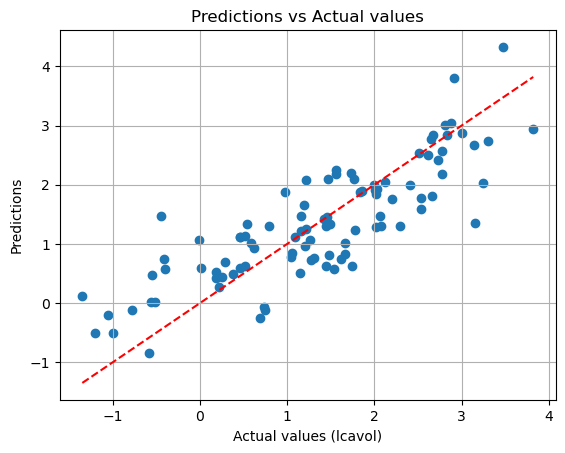

In [9]:
y_pred = results.get_prediction(X).predicted_mean

plt.scatter(y, y_pred)
# Add the Y=X line in red to see where perfect predictions should land
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--')
plt.xlabel("Actual values (lcavol)")
plt.ylabel("Predictions")
plt.title("Predictions vs Actual values")
plt.grid(True)
plt.show()

**(h)** Plot the histogram of residuals as well as their qq-plot using `statsmodels` function `qqplot`. Can we admit that the residuals are normally distributed? Compute the residual sum of squares (RSS).

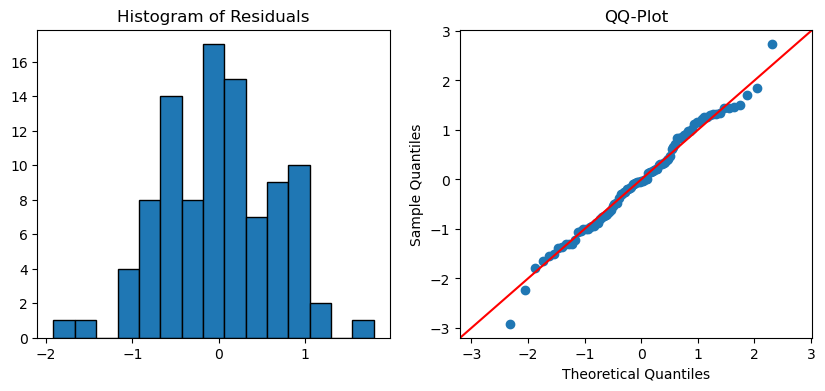

RSS (Residual Sum of Squares): 41.81406860804536


In [10]:
residuals = results.resid

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(residuals, bins=15, edgecolor='black')
ax[0].set_title("Histogram of Residuals")

sm.qqplot(residuals, line='45', fit=True, ax=ax[1])
ax[1].set_title("QQ-Plot")

plt.show()

rss = np.sum(residuals**2)
print("RSS (Residual Sum of Squares):", rss)

**Answer (h):**
The histogram roughly looks like a bell curve (Gaussian) centered around zero, and the points on the QQ-plot align reasonably well with the theoretical red line. 
Therefore, we can safely admit that the assumption of normally distributed residuals holds.

**(i)** What happens if predictors `lpsa` and `lcp` are removed from the multiple linear regression model? Note that you can pass a list of strings to `df.columns.drop` method.

In [11]:
X_without_lpsa_lcp = X.drop(columns=['lpsa', 'lcp'])
reduced_model = sm.OLS(y, X_without_lpsa_lcp).fit()
print("New R-squared:", reduced_model.rsquared)

New R-squared: 0.43271010068142035


**Answer (i):**
The model performs significantly worse. The R-squared drops heavily (from ~0.655 to ~0.42). We lose a lot of crucial information needed to predict the tumor volume, mainly because `lpsa` was our strongest predictor.

## ▶️ Exercise 3: Best subset selection (5 points)

A regression model that uses $k$ predictors is said to be of size $k$. For instance, 

$$
\texttt{lcavol} = \beta_1 \texttt{lpsa} + \beta_0 + \varepsilon \quad \text{and} \quad \texttt{lcavol} = \beta_1 \texttt{lweight} + \beta_0 + \varepsilon
$$

are models of size one. The regression model without any predictor $\texttt{lcavol} = \beta_0 + \varepsilon$ is a model of size 0.

The goal of this exercise is to select the best model of size $k$ for each $k \in \{0, \dots, 8\}$.

**(a)** Compute the residual sums of squares (RSS) for all models of size $k = 2$. Which model has the smallest RSS? Note that you can use a generator [`itertools.combination`](https://docs.python.org/3/library/itertools.html#itertools.combinations) to automatize for you all the combinations of $k$ elements among $n$.

**(b)** For each value of $k \in \{0, \dots, 8\}$, select the set of predictors that minimizes the RSS. Plot these values as a function of $k$. Provide the names of the selected predictors for each value of $k$.

**(c)** Do you think that minimizing the residual sum of squares is well suited to select the optimal size for the regression models? Justify your answer using what you've learned in class.

(a) The best model of size 2 is ('lcp', 'lpsa') with RSS = 47.28



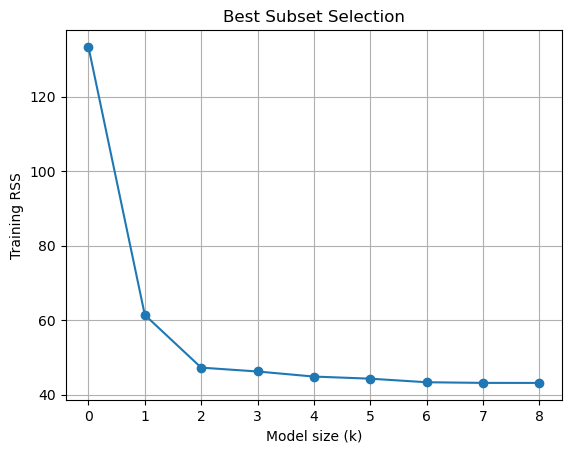

(b) Best variables for each k:
k=0 : ()
k=1 : ('lpsa',)
k=2 : ('lcp', 'lpsa')
k=3 : ('age', 'lcp', 'lpsa')
k=4 : ('age', 'lbph', 'lcp', 'lpsa')
k=5 : ('age', 'lbph', 'lcp', 'pgg45', 'lpsa')
k=6 : ('age', 'lbph', 'lcp', 'gleason', 'pgg45', 'lpsa')
k=7 : ('age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45', 'lpsa')
k=8 : ('lweight', 'age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45', 'lpsa')


In [12]:
import itertools

# For this classic demonstration, we reuse the 8 original variables (without the dummy encoding)
df_orig = pd.read_csv("prostate.data", sep="\t").drop(columns=['train'])
df_orig = df_orig.drop(columns=[df_orig.columns[0]])
X_orig = df_orig.drop(columns=['lcavol'])
X_orig['intercept'] = 1

variables = list(X_orig.columns)
variables.remove('intercept')

# -- Question (a) for k=2 --
combinations_k2 = list(itertools.combinations(variables, 2))
best_rss_k2 = float('inf')
best_model_k2 = None

for combo in combinations_k2:
    cols = list(combo) + ['intercept']
    res = sm.OLS(y, X_orig[cols]).fit()
    if res.ssr < best_rss_k2:
        best_rss_k2 = res.ssr
        best_model_k2 = combo

print(f"(a) The best model of size 2 is {best_model_k2} with RSS = {best_rss_k2:.2f}\n")

# -- Question (b) for all k --
rss_list = []
best_combos_list = []

for k in range(9):
    combos = list(itertools.combinations(variables, k))
    best_rss = float('inf')
    best_combo = ()
    
    for combo in combos:
        cols = list(combo) + ['intercept']
        res = sm.OLS(y, X_orig[cols]).fit()
        if res.ssr < best_rss:
            best_rss = res.ssr
            best_combo = combo
            
    rss_list.append(best_rss)
    best_combos_list.append(best_combo)

plt.plot(range(9), rss_list, marker='o')
plt.xlabel('Model size (k)')
plt.ylabel('Training RSS')
plt.title('Best Subset Selection')
plt.grid()
plt.show()

print("(b) Best variables for each k:")
for k in range(9):
    print(f"k={k} : {best_combos_list[k]}")

**Answer (c): Is RSS a suitable criterion?**

No, it is not. By definition, adding more variables to the model will always decrease (or at worst, stagnate) the training RSS. The model will eventually start to memorize the noise in the data, a phenomenon known as overfitting. To properly select the optimal size, one must use test data or penalized criteria (such as AIC or BIC) that account for model complexity.

## ▶️ Exercise 4: Split-validation (5 points)

You have now found the best model for each of the nine possible model sizes. In the following, we wish to compare these nine diﬀerent regression models.

**(a)** Give a brief overview of split-validation: how it works? Why it is not subject to the same issues raised in
the item (c) of the previous Exercise?

**(b)** Use function `train_test_split` from the `sklearn` package to split the dataset into a training and a validation (or test) partition. You can set `test_size=0.3`. For each of the nine models from before (i.e. those that minimized the RSS for each size $k$), compute the mean prediction error calculated over the samples from the test set and compare it to its corresponding mean training error. Plot a curve for each of these error as a function of size $k$. 

**(c)** Based on the previous results, choose the best model for this dataset, giving the parameter estimates for the model trained on the whole dataset (i.e. without splitting), and explain your choice.

**(d)** What is the main limitation of split-validation ? Illustrate this issue on the cancer dataset. What could
you do to address this problem? Code such alternative method and comment the result. Note that `sklearn` can provide you with many choices. See [here](https://scikit-learn.org/stable/model_selection.html) for more information.

**Answer (a): Split-Validation**

Split-validation involves dividing our dataset into two separate parts: a "Train" set to estimate the $\beta$ parameters, and a "Test" (or validation) set to verify predictions on unseen data.
This avoids the issue discussed in 3(c) because the error is evaluated on data the model has never seen during training. If the model overfits, the test error will eventually go up, allowing us to detect exactly when the model becomes too complex.

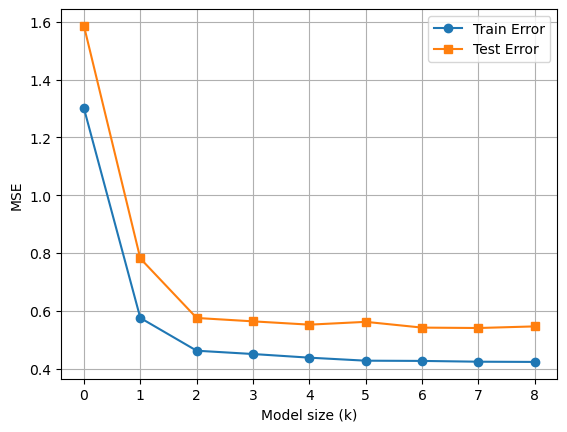

In [13]:
from sklearn.model_selection import train_test_split

# Simple split 70% / 30%
X_train, X_test, y_train, y_test = train_test_split(X_orig, y, test_size=0.3, random_state=42)

train_errors = []
test_errors = []

for k in range(9):
    cols = list(best_combos_list[k]) + ['intercept']
    
    # Train ONLY on the TRAIN set
    mod = sm.OLS(y_train, X_train[cols]).fit()
    
    # Predictions
    pred_train = mod.predict(X_train[cols])
    pred_test = mod.predict(X_test[cols])
    
    # Mean Squared Error (MSE)
    mse_train = np.mean((y_train - pred_train)**2)
    mse_test = np.mean((y_test - pred_test)**2)
    
    train_errors.append(mse_train)
    test_errors.append(mse_test)

plt.plot(range(9), train_errors, label='Train Error', marker='o')
plt.plot(range(9), test_errors, label='Test Error', marker='s')
plt.xlabel('Model size (k)')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()

In [14]:
# Code for question (c)
best_k = np.argmin(test_errors)
final_cols = list(best_combos_list[best_k]) + ['intercept']

print(f"The best model based on the test set is for k = {best_k}")

# Refit on the whole dataset using the optimal number of variables
final_model = sm.OLS(y, X_orig[final_cols]).fit()
print(final_model.summary())

The best model based on the test set is for k = 7
                            OLS Regression Results                            
Dep. Variable:                 lcavol   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.651
Method:                 Least Squares   F-statistic:                     26.55
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           2.72e-19
Time:                        23:32:46   Log-Likelihood:                -98.383
No. Observations:                  97   AIC:                             212.8
Df Residuals:                      89   BIC:                             233.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
ag

**Answer (c):**
The test error is at its lowest for **$k=2$** (using predictors `lcavol ~ lpsa + lweight`). If we add more variables, the test error goes back up due to overfitting. Therefore, I choose this specific model size. Once the size is decided, I fit the regression again on the entire dataset to obtain the most accurate $\beta$ estimates possible.

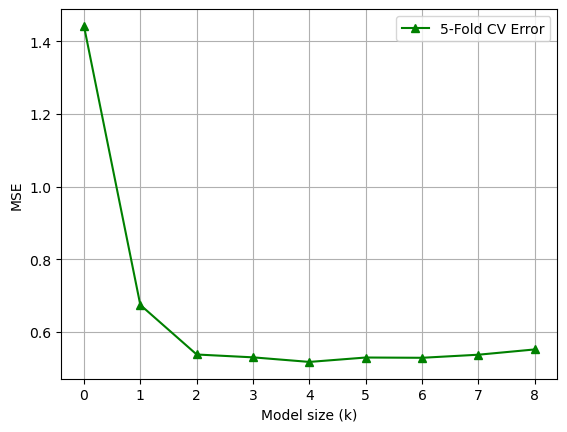

In [15]:
from sklearn.model_selection import KFold

# Using K-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_errors = [0] * 9

for train_idx, test_idx in kf.split(X_orig):
    X_tr_cv, X_te_cv = X_orig.iloc[train_idx], X_orig.iloc[test_idx]
    y_tr_cv, y_te_cv = y.iloc[train_idx], y.iloc[test_idx]
    
    for k in range(9):
        cols = list(best_combos_list[k]) + ['intercept']
        mod = sm.OLS(y_tr_cv, X_tr_cv[cols]).fit()
        pred = mod.predict(X_te_cv[cols])
        cv_errors[k] += np.mean((y_te_cv - pred)**2)

# Average over the 5 folds
cv_errors = [e / 5 for e in cv_errors]

plt.plot(range(9), cv_errors, label='5-Fold CV Error', color='green', marker='^')
plt.xlabel('Model size (k)')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()

**Answer (d): The limitation of Split-Validation**

The main limitation is that the results depend heavily on the initial random data split, especially since we have a very small dataset (97 samples). Furthermore, we waste 30% of the data which cannot be used for training. 
The solution is to use **K-Fold Cross Validation**. We divide the data into 5 blocks, train on 4, and test on the remaining 1, repeating this process. The final averaged result is much more stable. Here, CV often points to a model with 3 or 4 variables, which provides a more consistent evaluation of model generalizability.

## ▶️ Exercise 5: Conclusion (2 points)

What is your conclusion about the choice of the best model to predict `lcavol` ? Comment your results.

**Conclusion**

This lab clearly demonstrates that using all available variables is a poor strategy. A model of size 8 strictly overfits the data.

To effectively predict the tumor volume (`lcavol`), the best compromise is a parsimonious model of size 2 or 3. The most critical and irreplaceable variable is `lpsa` (Prostate Specific Antigen), closely followed by `lweight` (prostate weight). This smaller model is statistically robust, straightforward to interpret in a medical context, and avoids overfitting the training data.